In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\train_u6lujuX_CVtuZ9i (1).csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])


In [5]:
X = X.fillna(X.median())


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance by PC1 & PC2:", pca.explained_variance_ratio_)


Explained variance by PC1 & PC2: [0.15702469 0.12088451 0.09984993 0.09363165 0.08817304]


In [16]:
X_pca

array([[-0.95917069, -0.93413737],
       [ 0.22297572,  0.27904162],
       [-0.5586004 , -0.0025735 ],
       ...,
       [ 1.35988056, -0.30979009],
       [ 1.20540628,  0.32529653],
       [-1.44879271, -1.64862421]])

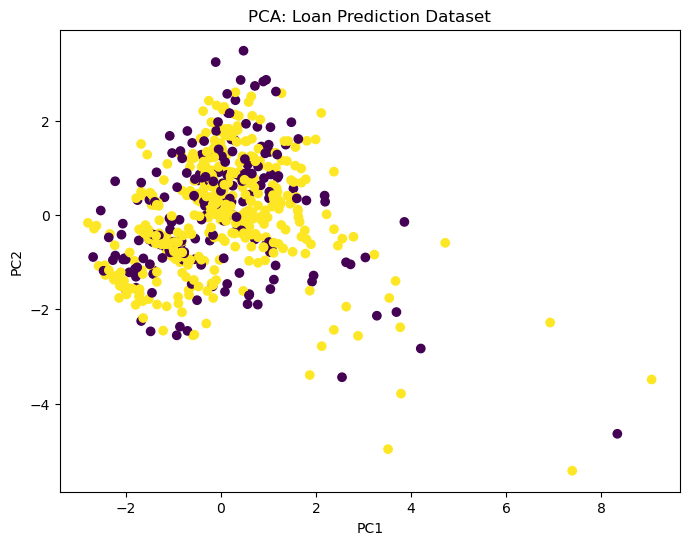

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y.map({'Y':1,'N':0}), cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Loan Prediction Dataset")
plt.show()


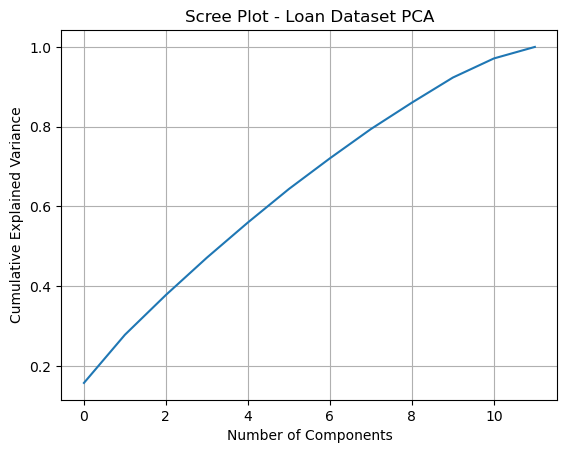

In [12]:
import numpy as np

pca_full = PCA().fit(X_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot - Loan Dataset PCA")
plt.grid(True)
plt.show()


In [18]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

print(loadings)


ValueError: Shape of passed values is (12, 5), indices imply (12, 2)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

pca_model = PCA(n_components=10)
X_pca_model = pca_model.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca_model, y, test_size=0.2, random_state=42)

clf = SVC()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Model Accuracy with PCA:", accuracy_score(y_test, y_pred))


Model Accuracy with PCA: 0.7967479674796748
